In [44]:
import PINN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from anndata import AnnData
import scvelo as scv
# import cellrank as cr
from sklearn.metrics.pairwise import euclidean_distances
from matplotlib import rcParams
rcParams['figure.figsize'] = (5, 5)
import random
random.seed(123)
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', 'thistle', 'red', 'darkred']) 
import warnings
warnings.filterwarnings("ignore")

In [2]:
adata_ori = sc.read('adata_metaclone_10_linkage_average_20250319.h5ad')
adata_ori

AnnData object with n_obs × n_vars = 179557 × 33696
    obs: 'library', 'dataset', 'sample', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'phase', 'S_score', 'G2M_score', 'condition', 'replicate', 'lib_id', 'leiden', 'LEIDEN', 'cell_type', 'cell_count', 'cell_proportion', 'pop_change', 'pop_change_fold', 'HSC_score', 'top_1_hsc_score', 'low_hsc_score', 'cell_barcode', 'SITT', 'key', 'LARRY_barcode', 'sample_id', 'LARRY_ID', 'barcode_rep', 'meta_number', 'meta_clone'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'LEIDEN_colors', 'condition_colors', 'dataset_colors', 'hvg', 'leiden', 'leiden_colors', 'lib_id_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'log_counts', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [3]:
hvgs = adata_ori.var.index[adata_ori.var.highly_variable]
hvgs

Index(['St18', 'Cpa6', 'Gm4956', 'Il1rl1', 'Il18r1', 'Gm4208', 'Adam23', 'Fn1',
       'Mreg', 'Pid1',
       ...
       'Ifit3', 'Dntt', 'Sorcs1', 'Cybb', 'Maob', 'Ndp', 'Gria3', 'Hs6st2',
       'Fgf13', 'Trap1a'],
      dtype='object', length=289)

In [4]:
adata = adata_ori[:,hvgs].copy()
adata

AnnData object with n_obs × n_vars = 179557 × 289
    obs: 'library', 'dataset', 'sample', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'phase', 'S_score', 'G2M_score', 'condition', 'replicate', 'lib_id', 'leiden', 'LEIDEN', 'cell_type', 'cell_count', 'cell_proportion', 'pop_change', 'pop_change_fold', 'HSC_score', 'top_1_hsc_score', 'low_hsc_score', 'cell_barcode', 'SITT', 'key', 'LARRY_barcode', 'sample_id', 'LARRY_ID', 'barcode_rep', 'meta_number', 'meta_clone'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'LEIDEN_colors', 'condition_colors', 'dataset_colors', 'hvg', 'leiden', 'leiden_colors', 'lib_id_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'log_counts', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [5]:
sc.tl.paga(adata, groups='cell_type')

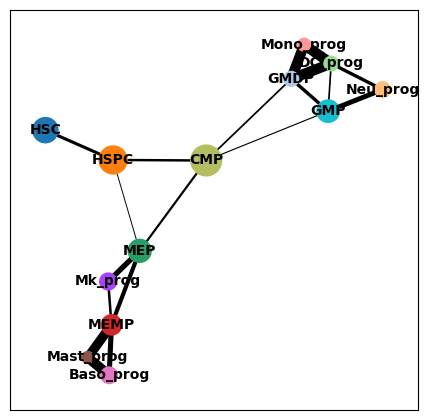

In [6]:
sc.pl.paga(adata, color='cell_type',threshold=0.05)

In [7]:
# sc.tl.diffmap(adata_ori)

In [8]:
# adata_ori.obsm['X_diffmap']

In [9]:
# adata_ori

In [10]:
adata_ctrl = adata[adata.obs['condition'] == "C", :].copy()
adata_ctrl

AnnData object with n_obs × n_vars = 82615 × 289
    obs: 'library', 'dataset', 'sample', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'phase', 'S_score', 'G2M_score', 'condition', 'replicate', 'lib_id', 'leiden', 'LEIDEN', 'cell_type', 'cell_count', 'cell_proportion', 'pop_change', 'pop_change_fold', 'HSC_score', 'top_1_hsc_score', 'low_hsc_score', 'cell_barcode', 'SITT', 'key', 'LARRY_barcode', 'sample_id', 'LARRY_ID', 'barcode_rep', 'meta_number', 'meta_clone'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'LEIDEN_colors', 'condition_colors', 'dataset_colors', 'hvg', 'leiden', 'leiden_colors', 'lib_id_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap', 'paga', 'cell_type_sizes', 'cell_type_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'log_counts', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [11]:
sc.tl.diffmap(adata_ctrl)

In [12]:
adata_ctrl.obsm['X_diffmap']

array([[ 2.9168162e-03, -1.7648541e-03,  2.8533558e-04, ...,
        -6.5864768e-04, -4.2429563e-04, -1.4591077e-03],
       [ 3.2120764e-03, -1.7215918e-03,  2.8616280e-04, ...,
        -6.6717563e-04,  3.6726089e-04,  1.8214280e-03],
       [ 3.2129139e-03, -1.9405832e-03,  2.3193394e-04, ...,
         3.3544147e-05, -6.1618694e-04, -2.2421582e-03],
       ...,
       [ 3.8618441e-03,  4.7930838e-03, -9.2398943e-03, ...,
        -3.6439260e-03,  3.2698888e-05, -6.8584067e-04],
       [ 4.3774727e-03,  8.5697253e-04,  1.6059658e-03, ...,
        -3.0720755e-03,  1.4188180e-04, -4.6601314e-03],
       [ 3.8374509e-03,  8.3813109e-03, -1.3541238e-02, ...,
         1.9401511e-02, -4.2226035e-03, -3.5615203e-03]], dtype=float32)

## Smooth HSC score and set a root cell

In [13]:
adata_hsc = adata_ctrl[adata_ctrl.obs['cell_type']=='HSC'].copy()
X_diffmap = adata_hsc.obsm['X_diffmap']
adata_hsc

AnnData object with n_obs × n_vars = 13372 × 289
    obs: 'library', 'dataset', 'sample', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'phase', 'S_score', 'G2M_score', 'condition', 'replicate', 'lib_id', 'leiden', 'LEIDEN', 'cell_type', 'cell_count', 'cell_proportion', 'pop_change', 'pop_change_fold', 'HSC_score', 'top_1_hsc_score', 'low_hsc_score', 'cell_barcode', 'SITT', 'key', 'LARRY_barcode', 'sample_id', 'LARRY_ID', 'barcode_rep', 'meta_number', 'meta_clone'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'LEIDEN_colors', 'condition_colors', 'dataset_colors', 'hvg', 'leiden', 'leiden_colors', 'lib_id_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap', 'paga', 'cell_type_sizes', 'cell_type_colors', 'diffmap_evals'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    layers: 'log_counts', 'raw_counts'
    obsp: 'conne

In [14]:
X_diffmap

array([[ 3.3750942e-03, -2.0371103e-03,  2.9518569e-04, ...,
        -3.8074030e-04, -5.7399680e-04, -2.4200487e-03],
       [ 3.0196365e-03, -1.9501287e-03,  3.0898440e-04, ...,
        -5.2354182e-04, -6.5593026e-04, -3.8783250e-03],
       [ 2.7126819e-03, -1.6974412e-03,  2.5361739e-04, ...,
        -5.0493231e-04, -5.3766952e-04, -2.5066631e-03],
       ...,
       [ 3.3831904e-03, -2.2123132e-03,  3.3075482e-04, ...,
        -7.4701813e-05, -4.4866756e-04, -4.2894385e-03],
       [ 3.9872797e-03, -2.3223683e-03,  3.0211065e-04, ...,
         1.1338984e-04, -5.8986270e-04, -2.0988632e-03],
       [ 2.9291515e-03, -1.9403228e-03,  3.1584778e-04, ...,
        -7.4063275e-05, -2.5691179e-04, -3.7100199e-03]], dtype=float32)

In [15]:
D_sub = euclidean_distances(X_diffmap, X_diffmap)
print(D_sub.shape)

(13372, 13372)


In [16]:
knn = D_sub
smoothed = []

for i in range(knn.shape[0]):
    tmp = np.array(knn[i])
    ind = np.argpartition(tmp, 10)[:10]
    neighbours = adata_hsc.obs.index[ind]
    
    adata_tmp = adata_hsc[neighbours,:].copy()
    
    array_tmp = np.append(adata_tmp.obs['HSC_score'], adata_hsc.obs['HSC_score'][1])
    knn_mean_tmp = array_tmp.mean()
    smoothed.append(knn_mean_tmp)

In [17]:
adata_hsc.obs['HSC_score_smoothed'] = smoothed

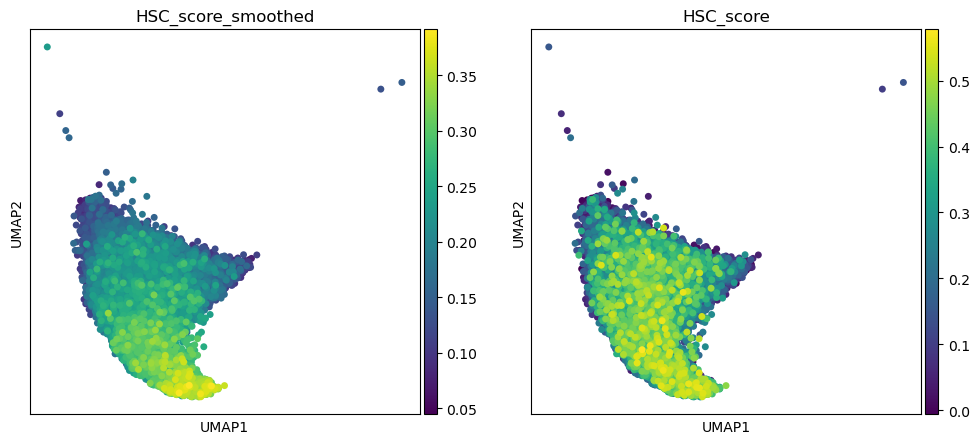

In [18]:
sc.pl.umap(adata_hsc, color=['HSC_score_smoothed','HSC_score'],s=100)

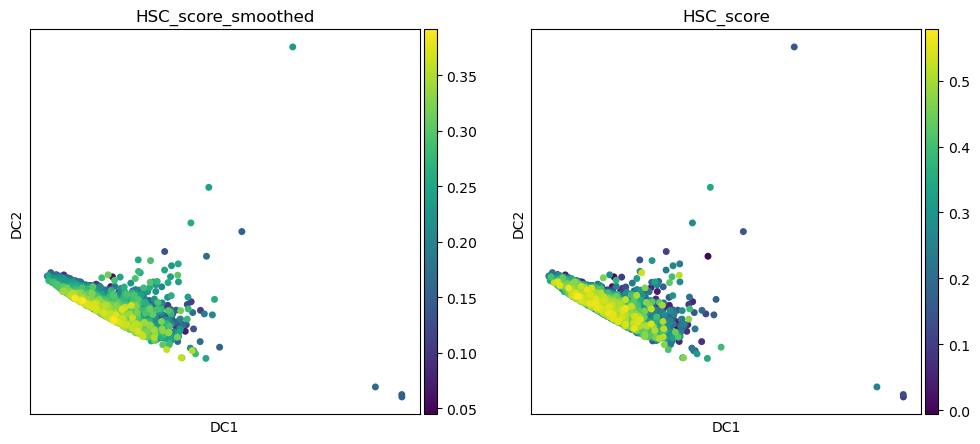

In [19]:
sc.pl.diffmap(adata_hsc, color=['HSC_score_smoothed','HSC_score'],s=100)

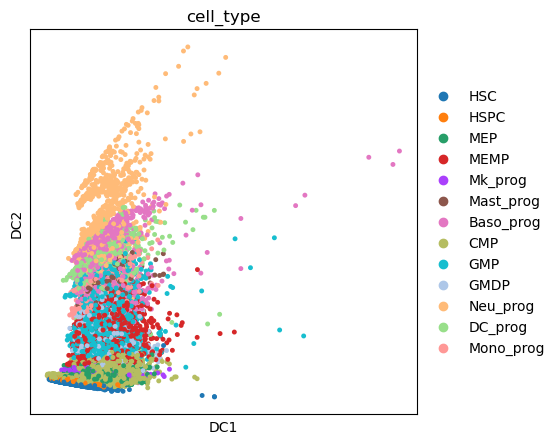

In [20]:
sc.pl.diffmap(adata_ctrl, color='cell_type',s=50)

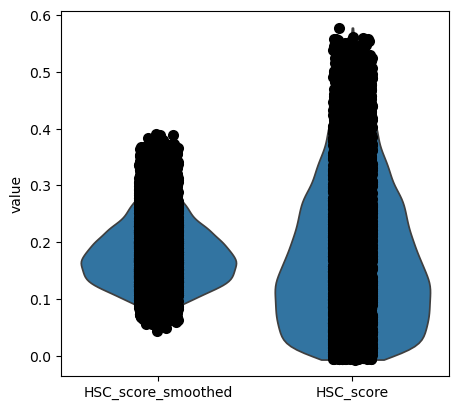

In [21]:
sc.pl.violin(adata_hsc, ['HSC_score_smoothed','HSC_score'],size=8)

In [22]:
adata_ctrl

AnnData object with n_obs × n_vars = 82615 × 289
    obs: 'library', 'dataset', 'sample', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'phase', 'S_score', 'G2M_score', 'condition', 'replicate', 'lib_id', 'leiden', 'LEIDEN', 'cell_type', 'cell_count', 'cell_proportion', 'pop_change', 'pop_change_fold', 'HSC_score', 'top_1_hsc_score', 'low_hsc_score', 'cell_barcode', 'SITT', 'key', 'LARRY_barcode', 'sample_id', 'LARRY_ID', 'barcode_rep', 'meta_number', 'meta_clone'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'LEIDEN_colors', 'condition_colors', 'dataset_colors', 'hvg', 'leiden', 'leiden_colors', 'lib_id_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap', 'paga', 'cell_type_sizes', 'cell_type_colors', 'diffmap_evals'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    layers: 'log_counts', 'raw_counts'
    obsp: 'conne

In [23]:
adata_ctrl.obs['root_sm'] = 'No'
root_idx = adata_hsc.obs['HSC_score_smoothed'].idxmax()
adata_ctrl.obs['root_sm']=adata_ctrl.obs['root_sm'].astype('str')
adata_ctrl.obs['root_sm'].loc[root_idx] = 'Yes'
adata_ctrl.obs['root_sm']=adata_ctrl.obs['root_sm'].astype('category')
adata_ctrl.uns['root_sm_colors'] = ['#CCCCCC','#b22222']

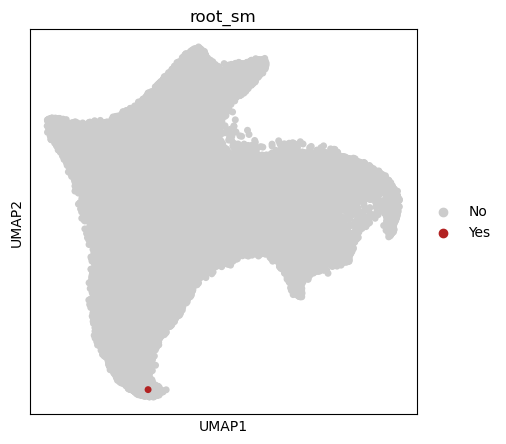

In [24]:
sc.pl.umap(adata_ctrl[adata_ctrl.obs.sort_values('root_sm',ascending=True).index], color='root_sm',s=100)

In [25]:
adata_ctrl.uns['iroot'] = np.flatnonzero(adata_ctrl.obs['root_sm']  == 'Yes')[0]

In [26]:
adata_ctrl.write('adata_iroot_20250513.h5ad')

In [3]:
adata_ctrl = sc.read_h5ad('../../data/adata_iroot_20250513.h5ad')

In [5]:
sc.tl.dpt(adata_ctrl)

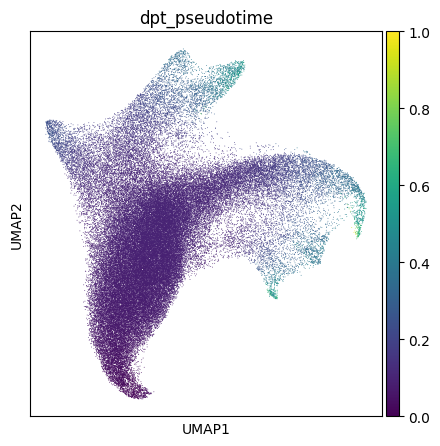

In [6]:
sc.pl.umap(adata_ctrl, color='dpt_pseudotime')

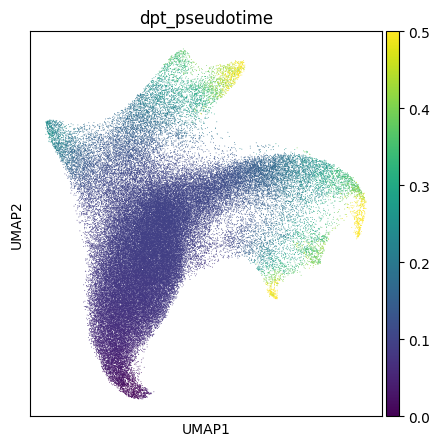

In [7]:
sc.pl.umap(adata_ctrl, color='dpt_pseudotime',vmax=0.5)

## add population size into the adata

In [11]:
adata_ctrl

AnnData object with n_obs × n_vars = 82615 × 289
    obs: 'library', 'dataset', 'sample', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'phase', 'S_score', 'G2M_score', 'condition', 'replicate', 'lib_id', 'leiden', 'LEIDEN', 'cell_type', 'cell_count', 'cell_proportion', 'pop_change', 'pop_change_fold', 'HSC_score', 'top_1_hsc_score', 'low_hsc_score', 'cell_barcode', 'SITT', 'key', 'LARRY_barcode', 'sample_id', 'LARRY_ID', 'barcode_rep', 'meta_number', 'meta_clone', 'root_sm', 'dpt_pseudotime'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'LEIDEN_colors', 'cell_type_colors', 'cell_type_sizes', 'condition_colors', 'dataset_colors', 'diffmap_evals', 'hvg', 'iroot', 'leiden', 'leiden_colors', 'lib_id_colors', 'log1p', 'neighbors', 'paga', 'pca', 'root_sm_colors', 'sample_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'

In [10]:
adata_ctrl.uns['iroot']

13308

In [19]:
adata = adata_ctrl


In [30]:
cellcount_df = adata.obs.groupby(['day','sample_id']).agg({'dataset':'count'}).reset_index()
cellcount_df

,day,sample_id,dataset
0,0,C1,7894
1,0,C2,8419
2,0,C3,7673
3,4,C1,8022
4,4,C2,7159
5,4,C3,8332
6,9,C1,5816
7,9,C2,4542
8,9,C3,4974
9,15,C1,6502


In [35]:
pop_dict = {}
pop_dict['t'] = sorted(adata.obs.day.unique())
pop_dict['mean'] = cellcount_df.groupby('day').agg({'dataset':'mean'})['dataset'].values
pop_dict['var'] = cellcount_df.groupby('day').agg({'dataset':'std'})['dataset'].values
pop_dict['n_lib'] = cellcount_df.groupby("day").agg({'dataset':'count'})['dataset'].values.tolist()

In [40]:
pop_dict['mean']

array([7995.33333333, 7837.66666667, 5110.66666667, 6594.66666667])

In [37]:
adata.uns['pop'] = pop_dict

In [38]:
adata.write('adata_iroot_20250513.h5ad')

In [43]:
import PINN

## Compute a Pseudotime Kernel and a GPCCA estimator for terminal states

### Terminal state estimation

In [8]:
adata_ori


NameError: name 'adata_ori' is not defined

In [34]:
hvgs = adata_ori.var.index[adata_ori.var.highly_variable]
hvgs


Index(['St18', 'Cpa6', 'Gm4956', 'Il1rl1', 'Il18r1', 'Gm4208', 'Adam23', 'Fn1',
       'Mreg', 'Pid1',
       ...
       'Ifit3', 'Dntt', 'Sorcs1', 'Cybb', 'Maob', 'Ndp', 'Gria3', 'Hs6st2',
       'Fgf13', 'Trap1a'],
      dtype='object', length=289)

In [39]:
adata = adata_ctrl[:,hvgs].copy()
adata


AnnData object with n_obs × n_vars = 82615 × 289
    obs: 'library', 'dataset', 'sample', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'phase', 'S_score', 'G2M_score', 'condition', 'replicate', 'lib_id', 'leiden', 'LEIDEN', 'cell_type', 'cell_count', 'cell_proportion', 'pop_change', 'pop_change_fold', 'HSC_score', 'top_1_hsc_score', 'low_hsc_score', 'cell_barcode', 'SITT', 'key', 'LARRY_barcode', 'sample_id', 'LARRY_ID', 'barcode_rep', 'meta_number', 'meta_clone', 'root_sm', 'dpt_pseudotime'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'LEIDEN_colors', 'condition_colors', 'dataset_colors', 'hvg', 'leiden', 'leiden_colors', 'lib_id_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap', 'paga', 'cell_type_sizes', 'cell_type_colors', 'diffmap_evals', 'root_sm_colors', 'iroot'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_diffmap'
    varm: 'PCs'

In [40]:
adata.layers["spliced"] = adata[:,hvgs].X
adata.layers["unspliced"] = adata[:,hvgs].X
scv.pp.moments(adata, n_neighbors=30, n_pcs=50) # default 30

or is corrupted (e.g. due to subsetting). Consider recomputing with `pp.neighbors`.
computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [37]:
# # compute terminal states
# pk = cr.tl.kernels.PseudotimeKernel(adata)

# pk.compute_transition_matrix(threshold_scheme='soft',b=10.0,nu=0.5) # default b=10.0,nu=0.5
# #pk.compute_transition_matrix(threshold_scheme='hard')#,frac_to_keep=0.1)

In [41]:
from cellrank.kernels import PseudotimeKernel

pk = PseudotimeKernel(adata, time_key="dpt_pseudotime")
pk.compute_transition_matrix(threshold_scheme='soft', b=10.0, nu=0.5)

  0%|          | 0/82615 [00:00<?, ?cell/s]

PseudotimeKernel[n=82615, dnorm=False, scheme='soft', b=10.0, nu=0.5]

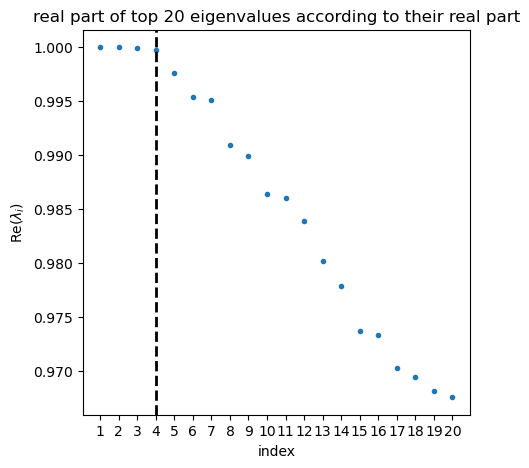

In [43]:
from cellrank.estimators import GPCCA

g_fwd = GPCCA(pk)
g_fwd.compute_schur(n_components=20)
g_fwd.plot_spectrum(real_only=True)

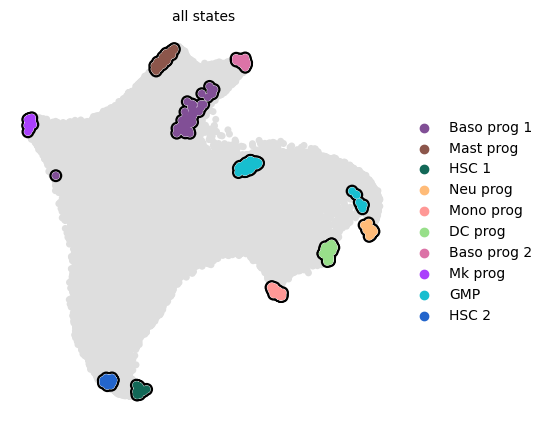

In [52]:
g_fwd.compute_macrostates(n_states=10, cluster_key="cell_type",n_cells=50) # n_cells default=30
#g_fwd.compute_macrostates(n_states=20, cluster_key="predicted.id",n_cells=10) # n_cells default=30

g_fwd.plot_macrostates(
    which="all",
    discrete=True, 
    legend_loc="right", 
    size=100, 
    basis="umap"
)

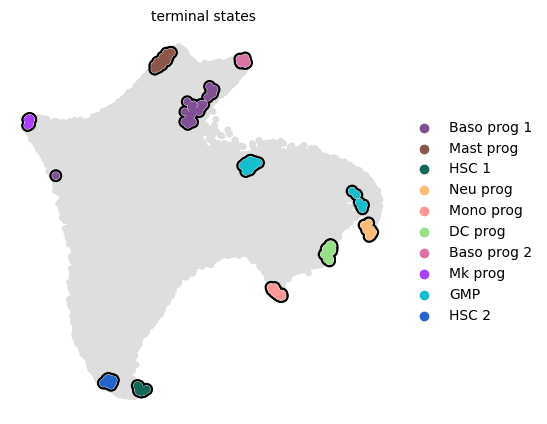

In [53]:
# Then predict which of these macrostates are terminal
g_fwd.predict_terminal_states()

g_fwd.plot_macrostates(
    which="terminal",
    discrete=True, 
    legend_loc="right", 
    size=100, 
    basis="umap"
)

In [57]:
g_fwd.set_terminal_states(['Mk_prog', 'Mast_prog', 'Baso_prog_2', 'Neu_prog', 'DC_prog', 'Mono_prog'], n_cells=50)

# Then rename them
g_fwd.rename_terminal_states({'Mk_prog': 'Mk', 
                             'Mast_prog': 'Mast',
                             'Baso_prog_2': 'Baso',
                             'Neu_prog': 'Neu',
                             'DC_prog': 'DC',
                             'Mono_prog': 'Mono'})

GPCCA[kernel=PseudotimeKernel[n=82615], initial_states=None, terminal_states=['Baso', 'DC', 'Mast', 'Mk', 'Mono', 'Neu']]

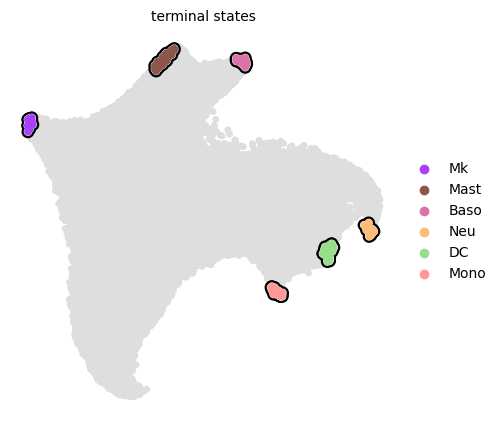

In [58]:
g_fwd.plot_macrostates(which="terminal", discrete=True, legend_loc="right", size=100, basis="umap")

In [60]:
g_fwd.compute_fate_probabilities(tol=1e-10)

  0%|          | 0/6 [00:00<?, ?/s]

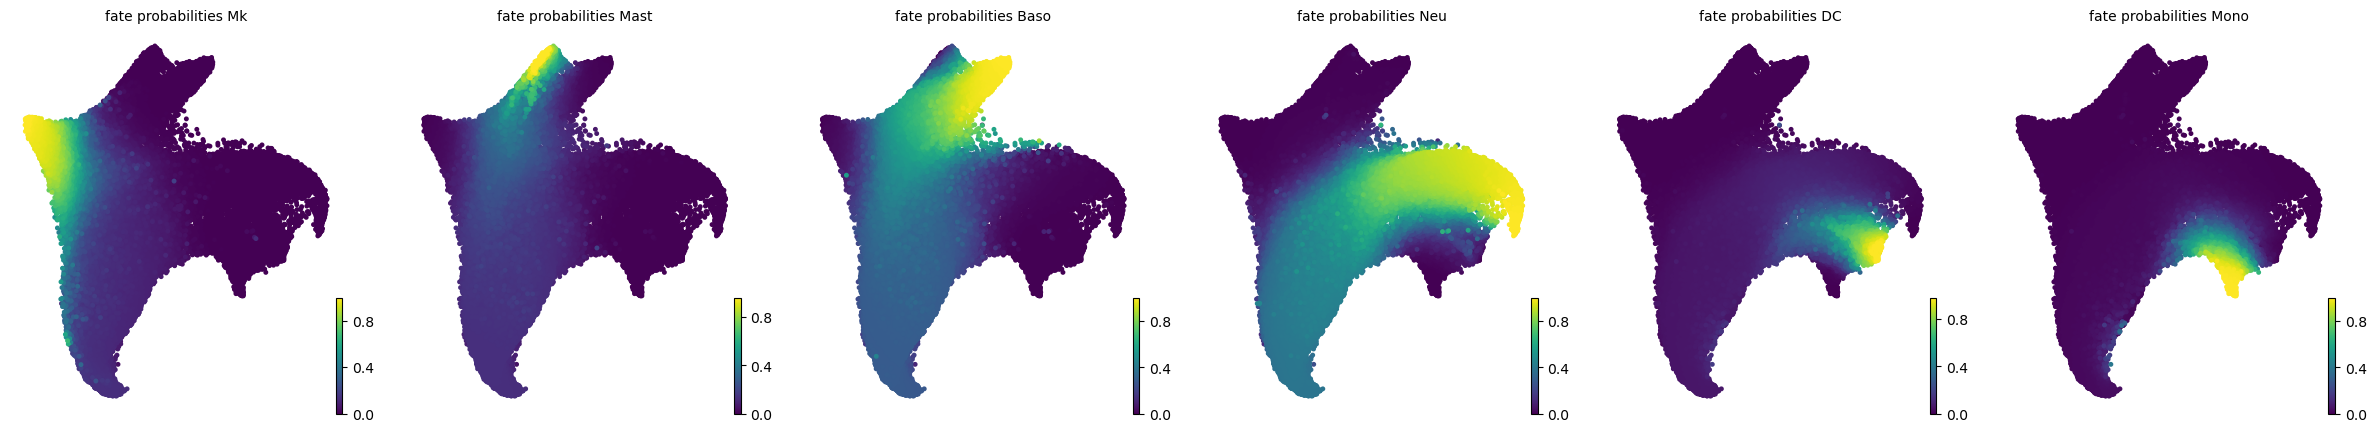

In [62]:
g_fwd.plot_fate_probabilities(same_plot=False, size=50, basis="umap")

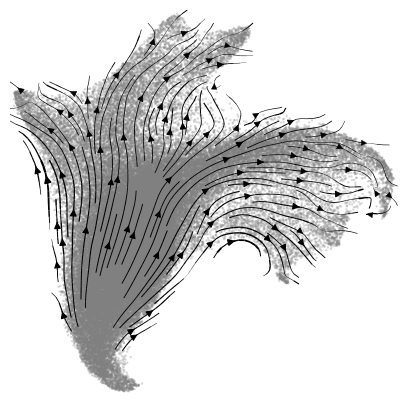

In [64]:
pk.plot_projection(basis="umap")

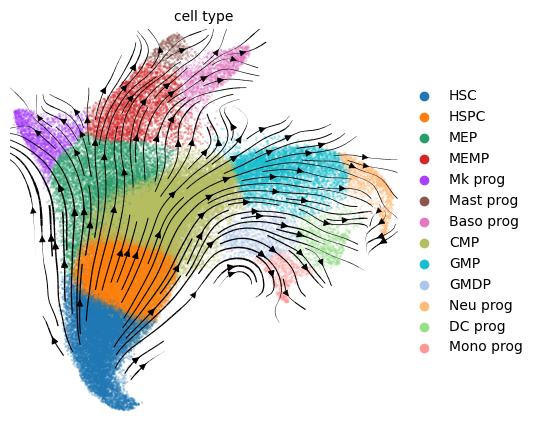

In [65]:
# Visualising the directed transition matrix computed using the KNN graph and CytoTRACE pseudotime.
# Looks like velocity, but this is NOT velocity.
scv.pl.velocity_embedding_stream(
    adata, color="cell_type", vkey="T_fwd", basis="umap", legend_loc="right",smooth=0.8
)

## Fate probability

In [66]:
adata.uns['velocity_graph'] = adata.obsp['connectivities']

In [73]:
# Fix for a known bug in scVelo
adata.uns['neighbors']['distances'] = adata.obsp['distances']
adata.uns['neighbors']['connectivities'] = adata.obsp['connectivities']

In [77]:
adata

AnnData object with n_obs × n_vars = 82615 × 289
    obs: 'library', 'dataset', 'sample', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'phase', 'S_score', 'G2M_score', 'condition', 'replicate', 'lib_id', 'leiden', 'LEIDEN', 'cell_type', 'cell_count', 'cell_proportion', 'pop_change', 'pop_change_fold', 'HSC_score', 'top_1_hsc_score', 'low_hsc_score', 'cell_barcode', 'SITT', 'key', 'LARRY_barcode', 'sample_id', 'LARRY_ID', 'barcode_rep', 'meta_number', 'meta_clone', 'root_sm', 'dpt_pseudotime', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'LEIDEN_colors', 'condition_colors', 'dataset_colors', 'hvg', 'leiden', 'leiden_colors', 'lib_id_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap', 'paga', 'cell_type_sizes', 'cell_type_colors', 'diffmap_evals', 'root_sm_colors', 'iroot', 'schur_ma

In [78]:
# Check for NaNs in your data
print(np.isnan(adata.X).any())
print(np.isnan(adata.layers['spliced']).any())
print(np.isnan(adata.layers['unspliced']).any())

# If needed, replace NaNs with zeros or filter them out
adata = adata[:, ~np.isnan(adata.X).any(axis=0)]
adata

False
False
False


View of AnnData object with n_obs × n_vars = 82615 × 289
    obs: 'library', 'dataset', 'sample', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'phase', 'S_score', 'G2M_score', 'condition', 'replicate', 'lib_id', 'leiden', 'LEIDEN', 'cell_type', 'cell_count', 'cell_proportion', 'pop_change', 'pop_change_fold', 'HSC_score', 'top_1_hsc_score', 'low_hsc_score', 'cell_barcode', 'SITT', 'key', 'LARRY_barcode', 'sample_id', 'LARRY_ID', 'barcode_rep', 'meta_number', 'meta_clone', 'root_sm', 'dpt_pseudotime', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'LEIDEN_colors', 'condition_colors', 'dataset_colors', 'hvg', 'leiden', 'leiden_colors', 'lib_id_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap', 'paga', 'cell_type_sizes', 'cell_type_colors', 'diffmap_evals', 'root_sm_colors', 'iroot', '

In [81]:
scv.tl.velocity(adata, mode='steady_state')
scv.tl.velocity_graph(adata, n_jobs=1)

computing velocities
    finished (0:00:02) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
or is corrupted (e.g. due to subsetting). Consider recomputing with `pp.neighbors`.
computing velocity graph (using 1/76 cores)


  0%|          | 0/82615 [00:00<?, ?cells/s]

ValueError: need at least one array to concatenate

In [75]:
scv.tl.paga(
    adata,
    groups="cell_type",
    #root_key="initial_states_probs",
    end_key="term_states_fwd_probs",
    use_time_prior="dpt_pseudotime",
)

running PAGA using priors: ['dpt_pseudotime', 'term_states_fwd_probs']


ValueError: mismatching number of index arrays for shape; got 0, expected 2

In [ ]:
scv.pl.paga(adata, basis='umap', vkey='velocity', 
            node_size_scale=1.5, min_edge_width=2, 
            use_raw=False, size=50, alpha=0.1)

/home/ti283/.conda/envs/cellrank/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/home/ti283/.conda/envs/cellrank/lib/python3.8/site-packages/networkx/drawing/nx_pylab.py:677: MatplotlibDeprecationWarning: Passing *transOffset* without *offsets* has no effect. This behavior is deprecated since 3.5 and in 3.6, *transOffset* will begin having an effect regardless of *offsets*. In the meantime, if you wish to set *transOffset*, call collection.set_offset_transform(transOffset) explicitly.
  edge_collection = LineCollection(


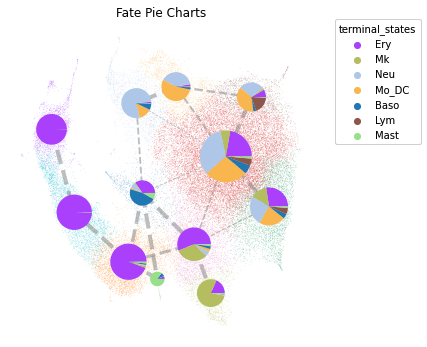

In [46]:
cr.pl.cluster_fates(
    adata,
    mode="paga_pie",
    cluster_key="CellSubType_mod",
    basis="umap",
    legend_kwargs={"loc": "top right out"},
    legend_loc=None,
    node_size_scale=5,
    edge_width_scale=1,
    max_edge_width=4,
    title="Fate Pie Charts",
    threshold=0.05
)

In [ ]:
adata.obs['Ery_prob']=g_fwd.absorption_probabilities['Ery']
adata.obs['Mk_prob']=g_fwd.absorption_probabilities['Mk']
adata.obs['Neu_prob']=g_fwd.absorption_probabilities['Neu']
adata.obs['Mo_prob']=g_fwd.absorption_probabilities['Mo_DC']
adata.obs['Baso_prob']=g_fwd.absorption_probabilities['Baso']
adata.obs['Lym_prob']=g_fwd.absorption_probabilities['Lym']
adata.obs['Mast_prob']=g_fwd.absorption_probabilities['Mast']

In [ ]:
sc.pl.violin(adata[adata.obs['predicted.id']=='Immature',:], keys= ['Ery_prob'],groupby='library')